In [1]:
from datetime import datetime, timezone, timedelta
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
#import glob
#import netCDF4 as nc
import xarray as xr
# import grib2io

#import cfgrib
import urllib
#import pygrib

sys.path.append('../sdpm_py_util')
sys.path.append('../web_util')

#import init_funs as initfuns
#import ocn_functions as ocnfuns
import plotting_functions as pltfuns
#import atm_functions as atmfuns
#import hind_functions as hindfuns
import grid_functions as grdfuns
#import web_functions as webfuns
from get_PFM_info import get_PFM_info

#import pickle
#import os
import subprocess

In [6]:
# make new waves 

import swan_functions as swanfuns 

# to make bnd waves file, need: 
# 1) cdip_ncs_to_dict_hind from swan_functions.py

swanfuns.cdip_ncs_to_dict_hind(modinfo_pkl_full)

# 2) mk_swan_bnd_file from swan_functions.py

mk_swan_bnd_file(fout,pkl_fnm)


# 3) if wind waves, also mk_swan_wnd_file from swan_functions.py



Now making dictionary of cdip data...
...done.

CDIP data saved as pickle file


In [8]:

# next, lets check the pickle file; 
wv_pkl = '/project/vboatwright/PFM_dir/simulations/LV4/Forc/LV4_swan_bnd.pkl' 
def load_pickle_file(file_path):
    import pickle
    import os 
    """
    Loads data from a pickle file.
    Args:
        file_path (str): The path to the pickle file.
    Returns:
        object: The unpickled object, or None if an error occurs.
    """
    try:
        with open(file_path, 'rb') as file:
            data = pickle.load(file)
        return data
    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

waves = load_pickle_file(wv_pkl)
waves

{'f': array([0.04  , 0.045 , 0.05  , 0.055 , 0.06  , 0.065 , 0.07  , 0.075 ,
        0.08  , 0.085 , 0.09  , 0.095 , 0.1013, 0.11  , 0.12  , 0.13  ,
        0.14  , 0.15  , 0.16  , 0.17  , 0.18  , 0.19  , 0.2   , 0.21  ,
        0.22  , 0.23  , 0.24  , 0.25  , 0.26  ], dtype=float32),
 'dir': array([155., 160., 165., 170., 175., 180., 185., 190., 195., 200., 205.,
        210., 215., 220., 225., 230., 235., 240., 245., 250., 255., 260.,
        265., 270., 275., 280., 285., 290., 295., 300., 305., 310., 315.,
        320., 325., 330., 335., 340., 345., 350., 355., 360.],
       dtype=float32),
 'time': array([datetime.datetime(2024, 11, 2, 0, 0),
        datetime.datetime(2024, 11, 2, 1, 0),
        datetime.datetime(2024, 11, 2, 2, 0),
        datetime.datetime(2024, 11, 2, 3, 0),
        datetime.datetime(2024, 11, 2, 4, 0),
        datetime.datetime(2024, 11, 2, 5, 0),
        datetime.datetime(2024, 11, 2, 6, 0),
        datetime.datetime(2024, 11, 2, 7, 0),
        datetime.dateti

In [11]:
# now, 2: make boundary file 

# fout = MI['lv4_forc_dir'] + '/' + MI['lv4_swan_bnd_file'] --> 
fout = '/project/vboatwright/PFM_dir/simulations/LV4/Forc/LV4_swan.bnd'
pkl_fnm = modinfo_pkl_full
swanfuns.mk_swan_bnd_file(fout,pkl_fnm)


CDIP pickle file loaded


In [4]:

# import init_funs_forecast as initfuns

import grid_functions as grdfuns
import init_funs as initfuns

driver_path = '/project/vboatwright/PFM_dir/PFM_for_rockfish/driver/'
pyutil_path = '/project/vboatwright/PFM_dir/PFM_for_rockfish/sdpm_py_util/'
simulation_path = '/project/vboatwright/PFM_dir/simulations/'

sys.path.append(driver_path)

# driver_run_hind_LV123 is a function now
from driver_run_hind_LV123 import driver_run_hind_LV123

input_py_full = pyutil_path+'boat_model_info_devel.py'
modinfo_pkl_full = simulation_path+'phm_modinfo_testing.pkl'

PFM = initfuns.get_model_info(modinfo_pkl_full)
print(PFM)


{'hind_river_type': 'IBWC_raw', 'hind_lv1_archive_dir': '/project/vboatwright/pfm_hindcast_data/archive/LV1/', 'hind_lv2_archive_dir': '/project/vboatwright/pfm_hindcast_data/archive/LV2/', 'hind_lv3_archive_dir': '/project/vboatwright/pfm_hindcast_data/archive/LV3/', 'hind_lv4_archive_dir': '/project/vboatwright/pfm_hindcast_data/archive/LV4/', 'hind_river_archive_dir': '/project/vboatwright/pfm_hindcast_data/archive/river_ncs/', 'lv1_bottom_roughness': 0.0007, 'lv2_bottom_roughness': 0.0007, 'lv3_bottom_roughness': 0.0007, 'lv4_bottom_roughness': 0.0007, 'swan_wind_wave_generation': False, 'forecast_days': 1.0, 'hindcast_duration': 12, 'auto_start_hind': True, 'sim_start_time': datetime.datetime(2024, 11, 1, 0, 0), 'sim_end_time': datetime.datetime(2024, 11, 13, 0, 0), 'sim_time_1': datetime.datetime(2024, 11, 2, 0, 0), 'sim_time_2': datetime.datetime(2024, 11, 3, 0, 0), 'levels_to_run': ['LV1', 'LV2', 'LV3', 'LV4'], 'atm_hind_dir': '/project/vboatwright/pfm_hindcast_data/model_forci

In [3]:
def cdip_wave_grabber(fin,vars,fout):
    # this is the function that is parallelized
    # the input is url: the hycom url to get data from
    # dtff: the time stamp of the forecast, ie, the file we want
    # aa: a box that defines the region of interest
    # PFM: used to set the path of where the .nc files go
    # dstr_ft: the date string of the forecast model run. ie. the first
    #          time stamp of the forecast
        
    cmd_list = ['ncks','-q','-D','0','-v', vars, fin ,'-4', '-O', fout]
 
    # run ncks
#    ret1 = subprocess.call(cmd_list,stderr=subprocess.DEVNULL,stdout=subprocess.DEVNULL)
    ret1 = subprocess.call(cmd_list)
    return ret1


In [9]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def get_cdip_data(pkl_fnm):
    # this function gets all of the new hycom data as separate files for each field (ssh,temp,salt,u,v) and each time
    # and puts each .nc file in the directory for hycom data

    PFM=initfuns.get_model_info(pkl_fnm)

    yyyymmddhh = PFM['fetch_time'].strftime("%Y%m%d%H")

    url_0 = 'https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/misc/falk/forecast/F' 
    fn1s = (['2436','2428','2415','2385','2360','2335','2322','2310','2298','2285','2260','2235',	
             '2185','2135','2085','2035','1985','1885','1835','1785','1735','1685','1635','1585',
             '1545','1530','1515','1495','1475','1460','1445','1434','1422','1410','1404','1396',	
             '1388','1380','1372','1364','1356','1348','1340','1334','1330','1326','1322','1318',	
             '1314','1310','1306','1302','1298','1294','1290','1286','1285','1283','1281','1276',	
             '1271','1266','1261','1255','1245','1235','1230','1220','1210','1200','1190','1181',	
             '1161','1141','1121','1101','1081','1061','1041','1021','1001'])
    fn2 = '_ecmwf_fc.nc'
    varns = 'waveTime,waveHs,waveTp,waveDp,waveFrequency,waveDirection,waveDirectionalSpectrum,metaLatitude,metaLongitude'

    files_to_copy = []

    print(yyyymmddhh)
    
    with ThreadPoolExecutor() as executor:
        threads = []
        for ff in fn1s:
            fn = cdip_wave_grabber
            fnmin = url_0+ff+fn2
            fnmout = PFM['cdip_data_dir'] + '/' + 'cdip_' + ff + '_' + yyyymmddhh + '.nc' 
            files_to_copy.append(fnmout)
#           
#  fnmout = ('/scratch/PFM_Simulations/LV4_Forecast/Forc/cdip_data' + '/' 
#                    + 'cdip_' + ff + '_' + yyyymmddhh + '.nc')          
            args = [fnmin,varns,fnmout]
            kwargs = {} #
            # start thread by submitting it to the executor
            threads.append(executor.submit(fn, *args, **kwargs))
            
        for future in as_completed(threads):
                # retrieve the result
            result = future.result()
            #print(result)
                # report the result        

    archive_cdip = PFM['archive_cdip'] 
    if archive_cdip == 1:
        print('copying cdip .nc files to archive...')
        dir2 = PFM['cdip_archive_dir']
        for fname in files_to_copy:
            fn_end = os.path.basename(fname)
            fn_2 = dir2 + fn_end
            try:
                shutil.copy(fname, fn_2)
                #print(f"File '{source_file}' copied successfully to '{destination_directory}'")
            except FileNotFoundError:
                print(f"Error: Source file '{fname}' not found.")
            except Exception as e:
                print(f"An error occurred: {e}")



In [10]:
get_cdip_data(modinfo_pkl_full)

2024110100


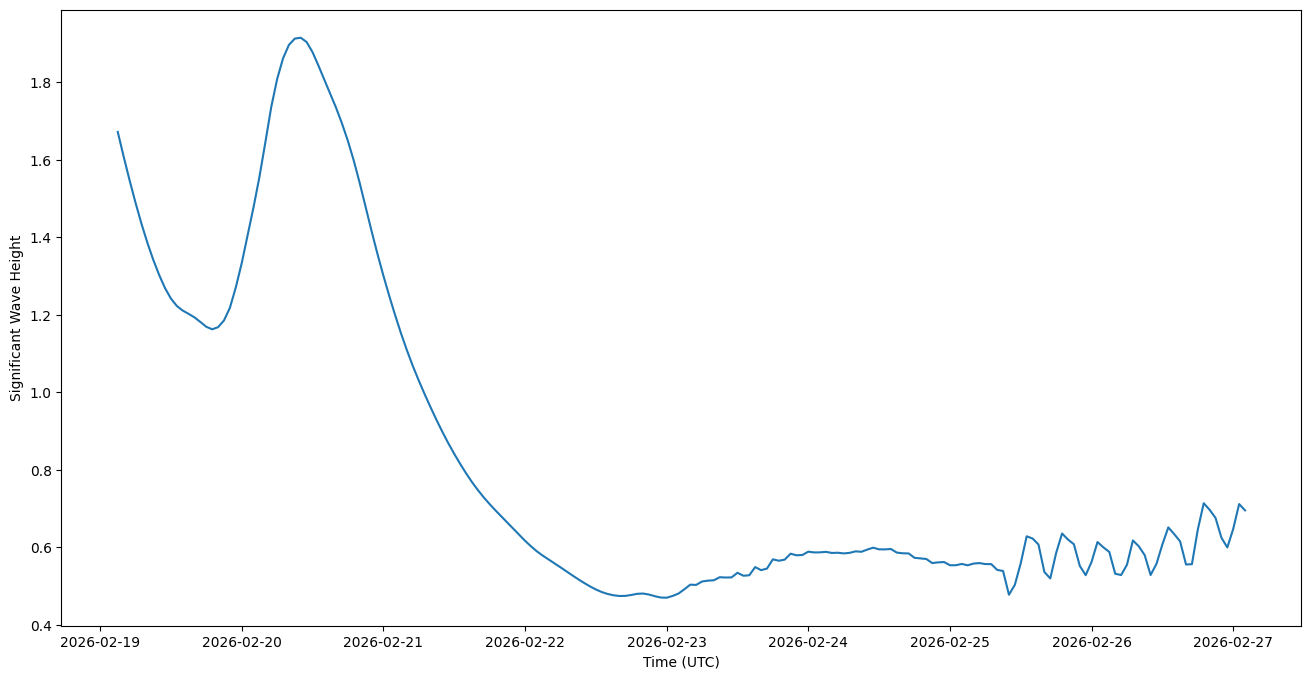

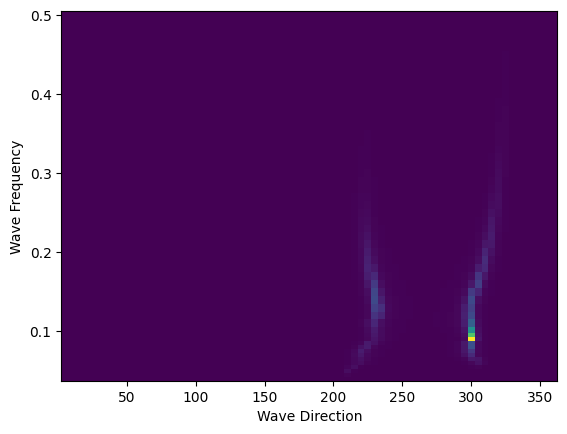

In [15]:
# okay it looks like the CDIP information should be correct.?
# lets check an individual file 

import netCDF4 as nc 
import datetime as datetime 
import matplotlib.dates as mdates 

path = '/project/vboatwright/pfm_hindcast_data/model_forcing/cdip_data/'
cdip_fn = f'{path}cdip_1245_2024110100.nc'

ds = nc.Dataset(cdip_fn)

wtime = ds['waveTime'][:]

d0 = datetime.datetime(1970,1,1) # UTC 
ts_array = [d0+datetime.timedelta(seconds=int(dd)) for dd in wtime]

wHs = ds['waveHs'][:]
wSpp = ds['waveDirectionalSpectrum'][:]
wfreq = ds['waveFrequency'][:]
wdir = ds['waveDirection']

plt.figure(figsize=(16,8))
plt.plot(ts_array,wHs)
plt.xlabel('Time (UTC)') 
plt.ylabel('Significant Wave Height')
myFmt = mdates.DateFormatter('%m')
plt.show()

plt.pcolormesh(wdir,wfreq,wSpp[0,:,:],shading='nearest')
plt.xlabel('Wave Direction') 
plt.ylabel('Wave Frequency')
plt.show()


In [17]:
wtime

masked_array(data=[1771470000, 1771473600, 1771477200, 1771480800,
                   1771484400, 1771488000, 1771491600, 1771495200,
                   1771498800, 1771502400, 1771506000, 1771509600,
                   1771513200, 1771516800, 1771520400, 1771524000,
                   1771527600, 1771531200, 1771534800, 1771538400,
                   1771542000, 1771545600, 1771549200, 1771552800,
                   1771556400, 1771560000, 1771563600, 1771567200,
                   1771570800, 1771574400, 1771578000, 1771581600,
                   1771585200, 1771588800, 1771592400, 1771596000,
                   1771599600, 1771603200, 1771606800, 1771610400,
                   1771614000, 1771617600, 1771621200, 1771624800,
                   1771628400, 1771632000, 1771635600, 1771639200,
                   1771642800, 1771646400, 1771650000, 1771653600,
                   1771657200, 1771660800, 1771664400, 1771668000,
                   1771671600, 1771675200, 1771678800, 1771682